## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.date_aligner import align_to_trading_day
from src.sentiment_classifier import classify_sentiment

## Load news data

In [2]:
news_df = load_data('../data/raw/raw_analyst_ratings.csv')

✅ Loaded: raw_analyst_ratings.csv
   Shape: (1407328, 6) rows × 6 columns
   Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


## Convert news date to datetime

In [3]:
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

## Remove rows with invalid dates

In [4]:
initial_len = len(news_df)
news_df = news_df.dropna(subset=['date'])
print(f"\n✅ Converted news dates: {initial_len - len(news_df)} rows removed")


✅ Converted news dates: 0 rows removed


## Extract date only (without time) for initial matching

In [5]:
news_df['date_only'] = news_df['date'].dt.date
news_df['hour'] = news_df['date'].dt.hour

print(f"\n📅 News Date Range: {news_df['date'].min()} to {news_df['date'].max()}")
print(f"   Total news articles: {len(news_df):,}")


📅 News Date Range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
   Total news articles: 1,407,328


## LOAD STOCK DATA

In [6]:
stock_ticker = "GOOG" 
stock_file = f'../data/raw/{stock_ticker}.csv'  # Adjust path

try:
    stock_df = load_data(stock_file)
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df = stock_df.sort_values('Date').reset_index(drop=True)
    print(f"   Date range: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
except FileNotFoundError:
    print(f"\n⚠️ Stock file not found: {stock_file}")
    print("   Creating sample trading calendar for demonstration...")
    
    # Create trading calendar if stock data not available
    trading_days = pd.date_range(
        start=news_df['date'].min().date(),
        end=news_df['date'].max().date(),
        freq='B'  # Business days only (excludes weekends)
    )
    stock_df = pd.DataFrame({'Date': trading_days})
    print(f"   Created trading calendar: {len(stock_df)} trading days")

# Create a set of trading dates for quick lookup
trading_dates = set(stock_df['Date'].dt.date)

print(f"\n📊 Trading Calendar:")
print(f"   Total trading days: {len(trading_dates)}")
print(f"   First trading day: {min(trading_dates)}")
print(f"   Last trading day: {max(trading_dates)}")

✅ Loaded: GOOG.csv
   Shape: (3774, 6) rows × 6 columns
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
   Date range: 2009-01-02 to 2023-12-29

📊 Trading Calendar:
   Total trading days: 3774
   First trading day: 2009-01-02
   Last trading day: 2023-12-29


## ALIGN NEWS TO TRADING DAYS

In [7]:
print("\n🔄 Aligning news dates to trading days...")

news_df['trading_date'] = news_df['date'].apply(
    lambda x: align_to_trading_day(x, trading_dates)
)

# Check alignment results
aligned_count = news_df['trading_date'].notna().sum()
unaligned_count = len(news_df) - aligned_count

print(f"\n📊 Alignment Results:")
print(f"   Successfully aligned: {aligned_count:,} ({aligned_count/len(news_df)*100:.1f}%)")
print(f"   Unaligned: {unaligned_count:,} ({unaligned_count/len(news_df)*100:.1f}%)")


🔄 Aligning news dates to trading days...

📊 Alignment Results:
   Successfully aligned: 1,407,328 (100.0%)
   Unaligned: 0 (0.0%)


## ANALYZE ALIGNMENT PATTERNS

In [8]:
# How many articles were published on weekends?
news_df['day_of_week'] = news_df['date'].dt.dayofweek
weekend_mask = news_df['day_of_week'].isin([5, 6])  # Saturday=5, Sunday=6
weekend_articles = weekend_mask.sum()

print(f"\n📅 Publication Day Analysis:")
print(f"   Weekend articles: {weekend_articles:,} ({weekend_articles/len(news_df)*100:.1f}%)")
print(f"   Weekday articles: {len(news_df)-weekend_articles:,}")

# Show examples of aligned dates
print(f"\n📋 Examples of date alignment:")
print("-" * 70)
examples = news_df[['date', 'trading_date', 'day_of_week']].head(10)
for _, row in examples.iterrows():
    original = row['date'].strftime('%Y-%m-%d %H:%M')
    aligned = row['trading_date'].strftime('%Y-%m-%d')
    is_weekend = "Weekend" if row['day_of_week'] >= 5 else "Weekday"
    print(f"   Original: {original:<22} → Aligned: {aligned:<12} ({is_weekend})")

# Count articles per trading day
articles_per_day = news_df.groupby('trading_date').size().sort_values(ascending=False)
print(f"\n📊 Articles per Trading Day:")
print(f"   Average: {articles_per_day.mean():.1f} articles/day")
print(f"   Max: {articles_per_day.max()} articles/day")
print(f"   Days with >100 articles: {(articles_per_day > 100).sum()}")


📅 Publication Day Analysis:
   Weekend articles: 24,225 (1.7%)
   Weekday articles: 1,383,103

📋 Examples of date alignment:
----------------------------------------------------------------------
   Original: 2020-06-05 14:30       → Aligned: 2020-06-05   (Weekday)
   Original: 2020-06-03 14:45       → Aligned: 2020-06-03   (Weekday)
   Original: 2020-05-26 08:30       → Aligned: 2020-05-26   (Weekday)
   Original: 2020-05-22 16:45       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 15:38       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 15:23       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 13:36       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 13:07       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 12:37       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 12:06       → Aligned: 2020-05-22   (Weekday)

📊 Articles per Trading Day:
   Average: 510.1 articles/day
   Max: 2739 articles/day
   Days with >100

In [9]:
print(f"   Unique stocks: {news_df['stock'].nunique()}")
print(f"   Top 10 stocks by article count:")
print(news_df['stock'].value_counts().head(10))

# Filter for specific stock
if stock_ticker in news_df['stock'].values:
    stock_news = news_df[news_df['stock'] == stock_ticker].copy()
    print(f"\n✅ Filtered news for {stock_ticker}: {len(stock_news)} articles")
else:
    print(f"\n⚠️ No news found for {stock_ticker}")
    stock_news = news_df.copy()
    print(f"   Using all news for analysis")

   Unique stocks: 6204
   Top 10 stocks by article count:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

✅ Filtered news for GOOG: 1199 articles


## Sentiment Analysis using NLTK VADER

In [10]:
# Download VADER lexicon (run once)
# nltk.download('vader_lexicon', quiet=True)

In [11]:
# Apply VADER to every headline and store the compound score
sia = SentimentIntensityAnalyzer()

# vader_compound is a number from -1.0 (very negative) to +1.0 (very positive)
stock_news['vader_compound'] = stock_news['headline'].apply(
    lambda text: sia.polarity_scores(str(text))['compound']
)

# Classify each score into a label using the standard VADER thresholds
stock_news['sentiment'] = stock_news['vader_compound'].apply(classify_sentiment)

# Show a few examples to build intuition
print("VADER SENTIMENT ANALYSIS RESULTS")

print('\n📊 Examples — Highest scoring headlines (most positive):')
print(stock_news.nlargest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

print('\n📊 Examples — Lowest scoring headlines (most negative):')
print(stock_news.nsmallest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

# Summary statistics
print(f"\n📊 Sentiment Distribution:")
print(stock_news['sentiment'].value_counts())
print(f"\n📊 Mean VADER score: {stock_news['vader_compound'].mean():.4f}")

VADER SENTIMENT ANALYSIS RESULTS

📊 Examples — Highest scoring headlines (most positive):
                                                                                                                                                                                                                     headline stock  vader_compound sentiment
     Alphabet shares are trading higher as the tech sector gains on positive coronavirus outlook. Optimism surrounding the virus has led to hopes of an upcoming return to economic activity, which would benefit the sector.  GOOG          0.9477  Positive
                                                                                                                                             Analyst: Amazon, Wayfair Big Winners From Impressive Online Holiday Sales Growth  GOOG          0.9081  Positive
UPDATE: KeyBanc On Google, Facebook, Twitter Sees 'advertisers gaining greater appreciation for the quality of impression, reach, frequency that is 

## CALCULATE DAILY STOCK RETURNS

In [12]:
# Calculate daily returns
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

print(f"\n✅ Daily returns calculated for {stock_ticker}")
print(f"   Date range: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
print(f"   Total trading days: {len(stock_df):,}")

# Display sample
print("\n📋 Sample of daily returns:")
print("-" * 60)
sample_returns = stock_df[['Date', 'Close', 'daily_return']].head(10)
for idx, row in sample_returns.iterrows():
    print(f"   {row['Date'].date()}: Close=${row['Close']:.2f}, Return={row['daily_return']:.2f}%")

# Summary statistics
print(f"\n📊 Daily Return Statistics (%):")
print(f"   Mean daily return: {stock_df['daily_return'].mean():.4f}%")
print(f"   Median daily return: {stock_df['daily_return'].median():.4f}%")
print(f"   Std deviation: {stock_df['daily_return'].std():.4f}%")
print(f"   Best day: {stock_df['daily_return'].max():.2f}%")
print(f"   Worst day: {stock_df['daily_return'].min():.2f}%")


✅ Daily returns calculated for GOOG
   Date range: 2009-01-02 to 2023-12-29
   Total trading days: 3,774

📋 Sample of daily returns:
------------------------------------------------------------
   2009-01-02: Close=$7.95, Return=nan%
   2009-01-05: Close=$8.12, Return=2.09%
   2009-01-06: Close=$8.26, Return=1.83%
   2009-01-07: Close=$7.97, Return=-3.61%
   2009-01-08: Close=$8.04, Return=0.99%
   2009-01-09: Close=$7.79, Return=-3.11%
   2009-01-12: Close=$7.74, Return=-0.76%
   2009-01-13: Close=$7.78, Return=0.52%
   2009-01-14: Close=$7.45, Return=-4.25%
   2009-01-15: Close=$7.40, Return=-0.66%

📊 Daily Return Statistics (%):
   Mean daily return: 0.0910%
   Median daily return: 0.0724%
   Std deviation: 1.7334%
   Best day: 16.05%
   Worst day: -11.10%


## Aggregate daily sentiment

In [13]:
# Group by trading_date and calculate average sentiment
daily_sentiment = stock_news.groupby('trading_date').agg({
    'vader_compound': 'mean',  # Average sentiment per day
    'headline': 'count'         # Number of articles per day
}).rename(columns={'vader_compound': 'avg_daily_sentiment', 'headline': 'article_count'})

# Reset index to make trading_date a column
daily_sentiment = daily_sentiment.reset_index()
daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])

print(f"✅ Aggregated {len(daily_sentiment)} trading days with sentiment data")
print(f"\n📋 Sample of daily aggregated sentiment:")
print(daily_sentiment.head(10))

✅ Aggregated 353 trading days with sentiment data

📋 Sample of daily aggregated sentiment:
  trading_date  avg_daily_sentiment  article_count
0   2018-11-13              0.00000              2
1   2018-11-14              0.40370              2
2   2018-11-15              0.21800              4
3   2018-11-16             -0.10175              2
4   2018-11-19              0.06100              2
5   2018-11-20              0.46645              2
6   2018-11-21              0.00000              1
7   2018-11-26              0.20140              3
8   2018-11-27              0.27940              5
9   2018-11-28              0.00000              1


## Calculate Pearson correlation coefficient

In [14]:
# Merge with stock returns
# Ensure stock_df has Date column and daily_return
merged = stock_df.merge(
    daily_sentiment, 
    left_on='Date', 
    right_on='trading_date', 
    how='inner'
)

print(f"✅ Merged data: {len(merged)} common trading days")

# Calculate Pearson correlation
correlation, p_value = pearsonr(merged['avg_daily_sentiment'], merged['daily_return'])

print(f"\n📊 Pearson Correlation Results:")
print(f"   Correlation coefficient: {correlation:.4f}")
print(f"   P-value: {p_value:.4e}")

# Interpretation
if abs(correlation) < 0.2:
    strength = "Very weak"
elif abs(correlation) < 0.4:
    strength = "Weak"
elif abs(correlation) < 0.6:
    strength = "Moderate"
elif abs(correlation) < 0.8:
    strength = "Strong"
else:
    strength = "Very strong"

direction = "positive" if correlation > 0 else "negative"
print(f"   Interpretation: {strength} {direction} correlation")

if p_value < 0.05:
    print(f"   Statistically significant (p < 0.05)")
else:
    print(f"   Not statistically significant (p >= 0.05)")

✅ Merged data: 353 common trading days

📊 Pearson Correlation Results:
   Correlation coefficient: 0.1693
   P-value: 1.4088e-03
   Interpretation: Very weak positive correlation
   Statistically significant (p < 0.05)


## Scatter plot with correlation annotation

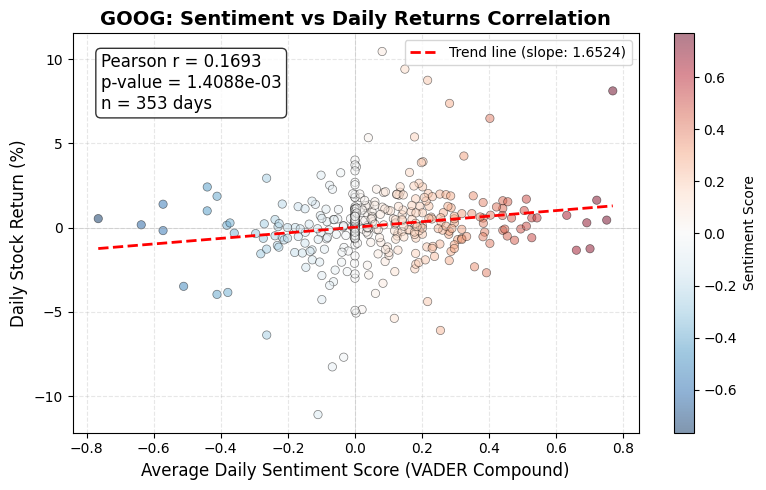

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot
scatter = ax.scatter(
    merged['avg_daily_sentiment'], 
    merged['daily_return'],
    alpha=0.5,
    c=merged['avg_daily_sentiment'],
    cmap='RdBu_r',
    edgecolors='black',
    linewidth=0.5
)

# Add trend line
z = np.polyfit(merged['avg_daily_sentiment'], merged['daily_return'], 1)
p = np.poly1d(z)
ax.plot(
    merged['avg_daily_sentiment'].sort_values(),
    p(merged['avg_daily_sentiment'].sort_values()),
    color='red',
    linewidth=2,
    linestyle='--',
    label=f'Trend line (slope: {z[0]:.4f})'
)

# Annotate correlation value
ax.annotate(
    f'Pearson r = {correlation:.4f}\np-value = {p_value:.4e}\nn = {len(merged)} days',
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Labels and title
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
ax.set_xlabel('Average Daily Sentiment Score (VADER Compound)', fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.set_title(f'{stock_ticker}: Sentiment vs Daily Returns Correlation', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Sentiment Score', fontsize=10)

plt.tight_layout()
plt.show()

## Classifying days by sentiment category


📋 Average Daily Return by Sentiment Category:
Sentiment Category  Avg Daily Return (%)  Std Dev  Number of Days
          Negative             -0.682820 2.313268              73
           Neutral              0.135058 1.784749             110
          Positive              0.499544 2.198897             170


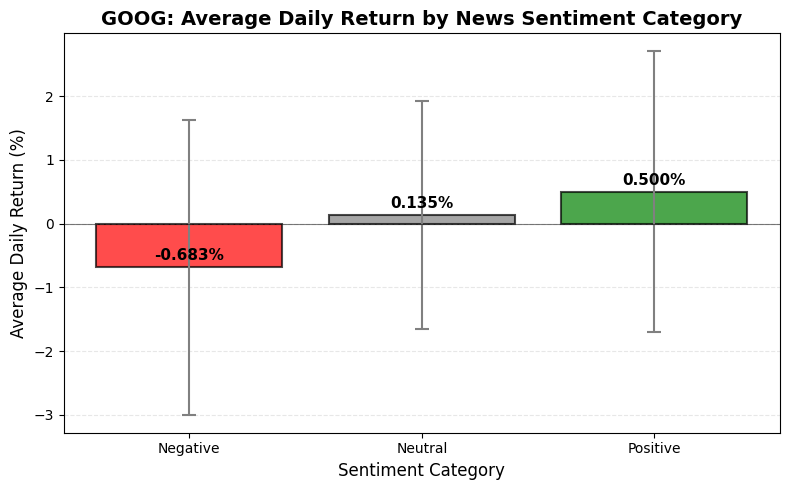

In [16]:
# Classify each day based on average sentiment score
merged['daily_sentiment_category'] = merged['avg_daily_sentiment'].apply(classify_sentiment)

# Calculate average daily return per category
category_returns = merged.groupby('daily_sentiment_category')['daily_return'].agg(['mean', 'std', 'count']).reset_index()
category_returns.columns = ['Sentiment Category', 'Avg Daily Return (%)', 'Std Dev', 'Number of Days']

print(f"\n📋 Average Daily Return by Sentiment Category:")
print(category_returns.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors for bars
colors_bar = {'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}
bar_colors = [colors_bar[cat] for cat in category_returns['Sentiment Category']]

# Create bar chart
bars = ax.bar(
    category_returns['Sentiment Category'],
    category_returns['Avg Daily Return (%)'],
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.7
)

# Add error bars (standard deviation)
ax.errorbar(
    category_returns['Sentiment Category'],
    category_returns['Avg Daily Return (%)'],
    yerr=category_returns['Std Dev'],
    fmt='none',
    color='black',
    capsize=5,
    capthick=1.5,
    ecolor='gray'
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.3f}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8)

# Labels and title
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
ax.set_title(f'{stock_ticker}: Average Daily Return by News Sentiment Category', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

## Interpretation

In [17]:
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 80)

print(f"""
Stock: {stock_ticker}
├── Trading days with news: {len(daily_sentiment)}
├── Common days with returns: {len(merged)}
├── Pearson correlation: {correlation:.4f}
├── P-value: {p_value:.4e}
└── Conclusion: {strength} {direction} correlation {'(statistically significant)' if p_value < 0.05 else '(not statistically significant)'}

Average Returns by Sentiment:
├── Positive sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Positive']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Positive']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Positive']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Positive']) > 0 else 0:.3f}%
├── Neutral sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Neutral']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Neutral']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Neutral']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Neutral']) > 0 else 0:.3f}%
└── Negative sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Negative']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Negative']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Negative']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Negative']) > 0 else 0:.3f}%
""")


CORRELATION ANALYSIS SUMMARY

Stock: GOOG
├── Trading days with news: 353
├── Common days with returns: 353
├── Pearson correlation: 0.1693
├── P-value: 1.4088e-03
└── Conclusion: Very weak positive correlation (statistically significant)

Average Returns by Sentiment:
├── Positive sentiment days: 170 days, avg return: 0.500%
├── Neutral sentiment days: 110 days, avg return: 0.135%
└── Negative sentiment days: 73 days, avg return: -0.683%



## Limitations of This Analysis

1. **Same-day correlation**: This analysis does not account for lag effects. 
   News published after market close may impact next day's returns, not the 
   current day's. Future work should test sentiment against forward returns.

2. **Confounding variables**: Stock prices are influenced by many factors 
   beyond news sentiment, including overall market movements, macroeconomic 
   indicators, and sector-specific trends not captured in these headlines.

3. **Sentiment tool constraints**: VADER was designed for social media text, 
   not financial news. Financial language often uses neutral terms 
   ("maintains", "reiterates") that may be misclassified.

4. **Temporal aggregation**: Averaging multiple headlines per day loses 
   information about the intensity and timing of sentiment signals.

5. **Correlation vs causation**: Even a statistically significant correlation 
   does not prove that news sentiment causes price movements — reverse 
   causality (prices driving sentiment) is possible.

6. **Headline-only analysis**: The analysis uses only headlines, not full 
   article text, which may contain important context and nuance.